Modelo Convolucional con aumento de datos y DROPOUT

## Librerias

In [5]:
# Graficación
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

# Modelado
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Datos

In [2]:
# Descargo dataset de MNIST (Numeros escritos a mano y etiquetados) y separo en set de entrenamiento (60k) y test (10k)
(X_entrenamiento, Y_entrenamiento), (X_pruebas, Y_pruebas) = mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [3]:
#Colocar los datos en la forma correcta (1, 28, 28, 1)
X_entrenamiento = X_entrenamiento.reshape(X_entrenamiento.shape[0], 28, 28, 1)
X_pruebas = X_pruebas.reshape(X_pruebas.shape[0], 28, 28, 1)

#Hacer 'one-hot encoding' de los resultados (e.g. en lugar de tener como resultado una sola neurona, tendre 10 donde solo el resultado correcto sera 1 y el resto 0)
Y_entrenamiento = to_categorical(Y_entrenamiento)
Y_pruebas = to_categorical(Y_pruebas)

#Convertir a float y normalizar para que aprenda mejor la red
X_entrenamiento = X_entrenamiento.astype('float32') / 255
X_pruebas = X_pruebas.astype('float32') / 255

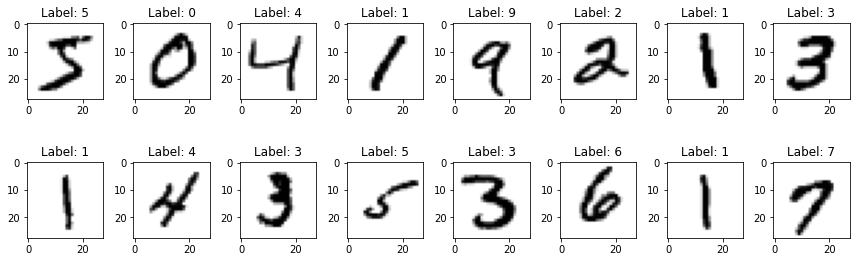

In [4]:
# Visualizo el dataset

filas = 2
columnas = 8
num = filas*columnas
imagenes = X_entrenamiento[0:num]
etiquetas = Y_entrenamiento[0:num]
fig, axes = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for i in range(num):
     ax = axes[i//columnas, i%columnas]
     ax.imshow(imagenes[i].reshape(28,28), cmap='gray_r')
     ax.set_title('Label: {}'.format(np.argmax(etiquetas[i])))
plt.tight_layout()
plt.show()

Aumento de datos

In [6]:
# Variables para controlar las transformaciones que se haran en el aumento de datos
# utilizando ImageDataGenerator de keras
rango_rotacion = 30
mov_ancho = 0.25
mov_alto = 0.25

#rango_inclinacion = 15 #De ser necesaria mas variedad se puede activar
rango_acercamiento = [0.5,1.5]

datagen = ImageDataGenerator(
    rotation_range = rango_rotacion,
    width_shift_range = mov_ancho,
    height_shift_range = mov_alto,
    zoom_range=rango_acercamiento,
    #shear_range=rango_inclinacion #De ser necesaria mas variedad se puede activar
)

datagen.fit(X_entrenamiento)

ANTES:



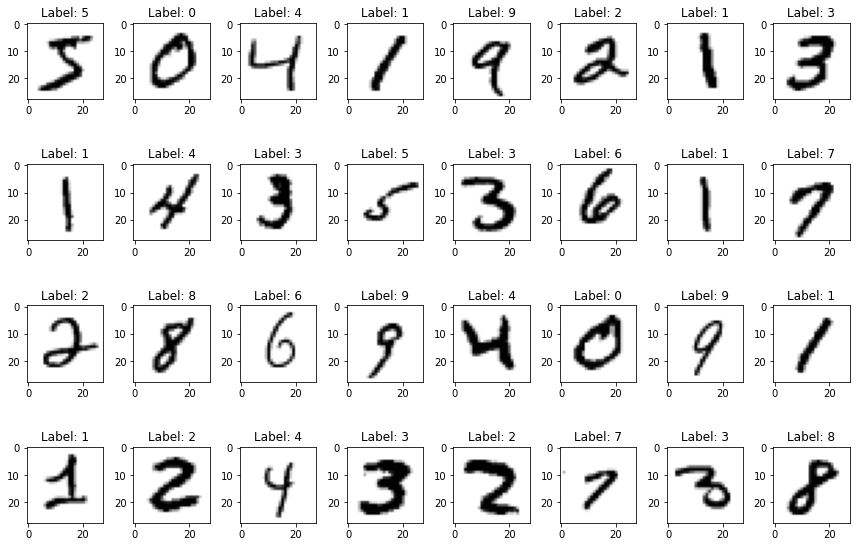

DESPUES:



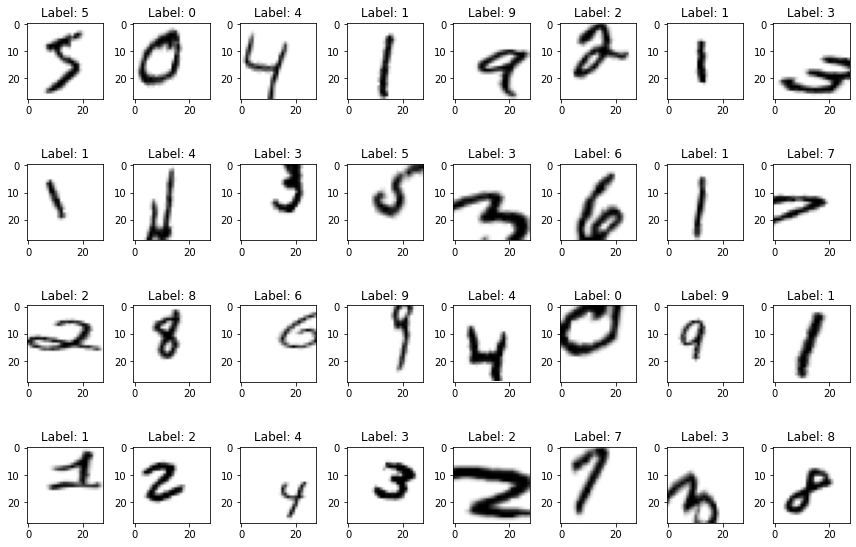

In [7]:
# Visualizo la transformación
filas = 4
columnas = 8
num = filas*columnas
print('ANTES:\n')
fig1, axes1 = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for i in range(num):
     ax = axes1[i//columnas, i%columnas]
     ax.imshow(X_entrenamiento[i].reshape(28,28), cmap='gray_r')
     ax.set_title('Label: {}'.format(np.argmax(Y_entrenamiento[i])))
plt.tight_layout()
plt.show()
print('DESPUES:\n')
fig2, axes2 = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for X, Y in datagen.flow(X_entrenamiento,Y_entrenamiento.reshape(Y_entrenamiento.shape[0], 10),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//columnas, i%columnas]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(np.argmax(Y[i]))))
     break
plt.tight_layout()
plt.show()

## Modelado

In [8]:
# Crear el modelo con neuronas convolucionales
modelo = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation="softmax")
])

#Compilación
modelo.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
#Los datos para entrenar saldran del datagen, de manera que sean generados con las transformaciones que indicamos
data_gen_entrenamiento = datagen.flow(X_entrenamiento, Y_entrenamiento, batch_size=32)

In [10]:
TAMANO_LOTE = 32

#Entrenar la red. Toma un buen rato! Ve por un café ;)
#Oye suscribete al canal!
print("Entrenando modelo...");
epocas=60
history = modelo.fit(
    data_gen_entrenamiento,
    epochs=epocas,
    batch_size=TAMANO_LOTE,
    validation_data=(X_pruebas, Y_pruebas),
    steps_per_epoch=int(np.ceil(60000 / float(TAMANO_LOTE))),
    validation_steps=int(np.ceil(10000 / float(TAMANO_LOTE)))
)

print("Modelo entrenado!");

Entrenando modelo...
Epoch 1/60
1875/1875 [==============================] - 16s 8ms/step - loss: 1.1523 - accuracy: 0.6149 - val_loss: 0.1744 - val_accuracy: 0.9475
Epoch 2/60
1875/1875 [==============================] - 15s 8ms/step - loss: 0.6725 - accuracy: 0.7832 - val_loss: 0.1297 - val_accuracy: 0.9623
Epoch 3/60
1875/1875 [==============================] - 16s 8ms/step - loss: 0.5540 - accuracy: 0.8210 - val_loss: 0.1020 - val_accuracy: 0.9703
Epoch 4/60
1875/1875 [==============================] - 16s 8ms/step - loss: 0.5024 - accuracy: 0.8371 - val_loss: 0.1009 - val_accuracy: 0.9698
Epoch 5/60
1875/1875 [==============================] - 15s 8ms/step - loss: 0.4678 - accuracy: 0.8489 - val_loss: 0.0856 - val_accuracy: 0.9749
Epoch 6/60
1875/1875 [==============================] - 16s 8ms/step - loss: 0.4469 - accuracy: 0.8559 - val_loss: 0.0860 - val_accuracy: 0.9761
Epoch 7/60
1875/1875 [==============================] - 15s 8ms/step - loss: 0.4215 - accuracy: 0.8643 - val_

## Exportación

In [11]:
#Exportar el modelo para utilizar en web
modelo.save('numeros_cnn_AD_DO.h5')

#Convertirlo a tensorflow.js
!tensorflowjs_converter --input_format keras numeros_cnn_AD_DO.h5 exportacion/modelo_CNN_AD_DO

2023-02-15 18:53:52.352838: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'cudart64_110.dll'; dlerror: cudart64_110.dll not found
2023-02-15 18:53:52.352996: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
